# Part 6b: Deterministic continuous-time dynamical systems (ODEs)

As discucsed briefly in the introduction, `dynestyx` also supports inference in deterministic dynamical systems, such as those generated via an ordinary differential equation (ODE). In this tutorial, we show how to use the `ODESimulator` to perform Bayesian inference on the parameters of an ODE.

## The System

In this example, we'll use the Lorenz 63 model. The state is 3-dimensional, $x \in \mathbb{R}^3$, and the evolution will be specified as 

$$ \frac{\mathrm{d}}{\mathrm{d} t} x(t) = \left( \begin{bmatrix} -10 & 10 & 0 \\ \rho - x_2(t) & -1 & 0 \\ x_1(t) & 0 & \frac{-8}{3} \end{bmatrix} \right) x(t)$$

where the transition depends on some parameter $\rho$. 

Let's set up a probabilistic program for this dynamical system by placing a prior on $\rho$ and $x(t=0)$, and a Gaussian likelihood on $y(t_k) \,|\, x(t_k)$:

$$ \rho \sim U(10.0, 40.0), $$

$$ x(t=0) \sim \mathcal{N}(0, 2.0^2 I), $$

$$ y(t_k) \,|\, x_{t_k} \sim \mathcal{N}(0.0, 1.0^2).$$

$$ y(t_k) \mid x(t_k) \sim \mathcal{N}\big(\underbrace{\begin{bmatrix} 1 & 0 & 0 \end{bmatrix}}_{H} x(t_k), \underbrace{1.0^2}_R\big), $$

where $H$ is the linear observation matrix, in this case, selecting our observations as the first component $x_1(t_k)$, and $R$ is the observation covariance, in this case, the scalar $1.0$.

Our end goal will be inference of $x_0 \triangleq x(t=0)$ and $\rho$ given the data, i.e., $p(\rho, x_0 \,|\, y_{1:T})$. In this tutorial, we will obtain that by obtaining the posterior over all states, $p(\rho, x_{0:T} \,|\, y_{1:T})$, and then marginalizing the full posterior to obtain $p(\rho, x_0 \,|\, y_{1:T})$. This is juxtaposed to many of the other tutorials, such as in [the quickstart](../../quickstart/), where we first marginalized the dynamical system via a filter, and then sample from that marginalized model directly.

## Specifying the Model in `dynestyx`

To specify the model in `dynestyx`, we specify a `ContinuousStateEvolution` that does not include a diffusion.

In [1]:
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist

import dynestyx as dsx
from dynestyx import (
    ContinuousTimeStateEvolution,
    DynamicalModel,
    LinearGaussianObservation,
)

state_dim = 3
observation_dim = 1


def continuous_time_deterministic_l63_model(rho=None, obs_times=None, obs_values=None, predict_times=None):
    """Model that samples drift parameter rho and uses it in dynamics (ODE, no diffusion)."""
    rho = numpyro.sample("rho", dist.Uniform(10.0, 40.0), obs=rho)

    # Create the dynamical model with sampled rho
    dynamics = DynamicalModel(
        initial_condition=dist.MultivariateNormal(
            loc=jnp.zeros(state_dim), covariance_matrix=2.0**2 * jnp.eye(state_dim)
        ),
        state_evolution=ContinuousTimeStateEvolution(
            drift=lambda x, u, t: jnp.array(
                [
                    10.0 * (x[1] - x[0]),
                    x[0] * (rho - x[2]) - x[1],
                    x[0] * x[1] - (8.0 / 3.0) * x[2],
                ]
            )
        ),
        observation_model=LinearGaussianObservation(
            H=jnp.eye(observation_dim, state_dim),
            R=jnp.eye(observation_dim),
        ),
    )

    return dsx.sample("f", dynamics, obs_times=obs_times, obs_values=obs_values, predict_times=predict_times)

## Generating Samples From the Generative Model

As in our previous examples, we must specify a `dsx.simulators` object to tell `dynestyx` how to generate samples. For determeinistic, continuous-time dynamical systems, we call an `ODESimulator`. This is primarily a frontend for a conventional numerical solver, housed by `diffrax`, coupled with sampling from the observation model.

In [2]:
import jax.random as jr
from numpyro.infer import Predictive

from dynestyx import ODESimulator

obs_times = jnp.arange(start=0.0, stop=5.0, step=0.0025)

prng_key = jr.PRNGKey(0)
sde_solver_key, predictive_key = jr.split(prng_key, 2)

predictive_model = Predictive(continuous_time_deterministic_l63_model, num_samples=1)

with ODESimulator():
    synthetic_samples = predictive_model(predictive_key, rho=28.0, predict_times=obs_times)

We can visualize the resulting dynamical system and observations:

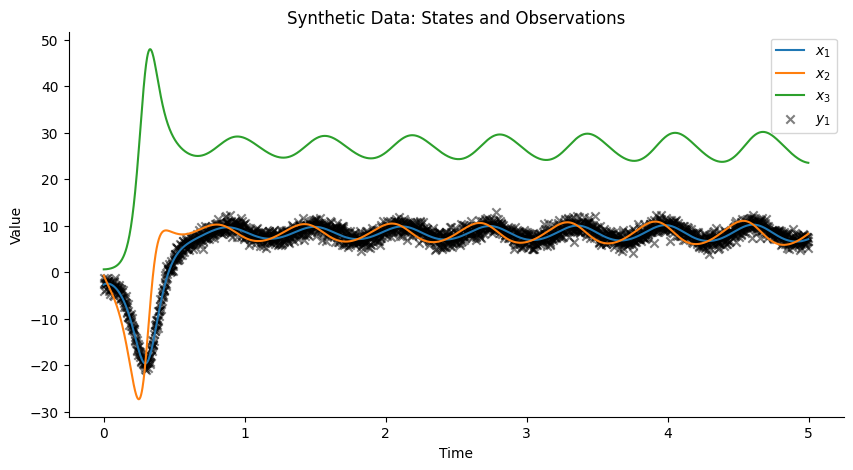

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

times = synthetic_samples["f_times"][0]
states = synthetic_samples["f_states"][0]
observations = synthetic_samples["f_observations"][0].squeeze()
state_colors = sns.color_palette("tab10", 3)

for d in range(3):
    plt.plot(times, states[:, d], label=fr"$x_{d + 1}$", color=state_colors[d])

plt.scatter(
    times,
    observations,
    label=r"$y_1$",
    marker="x",
    color="black",
    alpha=0.5,
)
plt.title("Synthetic Data: States and Observations")
plt.xlabel("Time")
plt.ylabel("Value")
sns.despine()
plt.legend()
plt.show()

We can also visualize in 3d to see the typical Lorenz attractor shape.

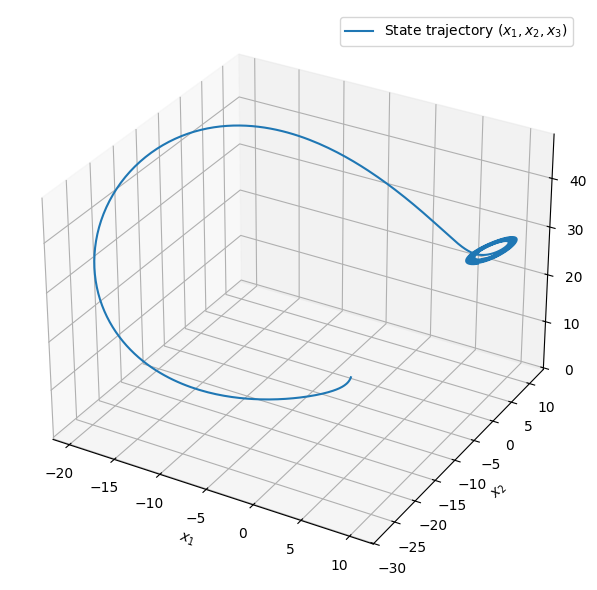

In [4]:
obs = synthetic_samples["f_observations"][0]

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot(
    synthetic_samples["f_states"][0][:, 0],
    synthetic_samples["f_states"][0][:, 1],
    synthetic_samples["f_states"][0][:, 2],
    label=r"State trajectory $(x_1, x_2, x_3)$",
)

ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_zlabel("$x_3$")
ax.legend()
plt.tight_layout()
plt.show()

## Bayesian Inference via Simulation

For a deterministic dynamical system, one option for inference is to deterministically solve the system -- given the initial state and system parameters -- and solve as a conventional probabilistic program. While this is not the most scalable solution for very long or high-dimensional time series (for those, we can use [probabilistic solvers](https://arxiv.org/abs/2110.11812), to be incorporated into `dynestyx` soon), it is reasonable for time series on the order of hundreds of points with moderate dimension, so long as the underlying ODE is relatively well-behaved.

To perform inference via this "unrolling" in `dynestyx`, we pass the observed values `obs_values` along with `obs_times` to the model:

The resulting model is directly compatible with `numpyro` inference tools, which will perform joint (parameter, state) inference, for example, using NUTS. The resulting inference will be quite slow -- we are running a numerical solver at every time step, that the inference method must backpropagate through -- but relatively accurate.

In [5]:
import jax.random as jr
from numpyro.infer import MCMC, NUTS

mcmc_key = jr.PRNGKey(42)

obs_values = synthetic_samples["f_observations"][0]

with ODESimulator():
    nuts_kernel = NUTS(continuous_time_deterministic_l63_model)
    mcmc = MCMC(nuts_kernel, num_samples=500, num_warmup=500)
    mcmc.run(mcmc_key, obs_times=obs_times, obs_values=obs_values)

posterior_samples = mcmc.get_samples()

sample: 100%|██████████| 1000/1000 [31:34<00:00,  1.89s/it, 95 steps of size 6.93e-02. acc. prob=0.93]  


The posterior of parameters, such as $\rho$, is thus available:

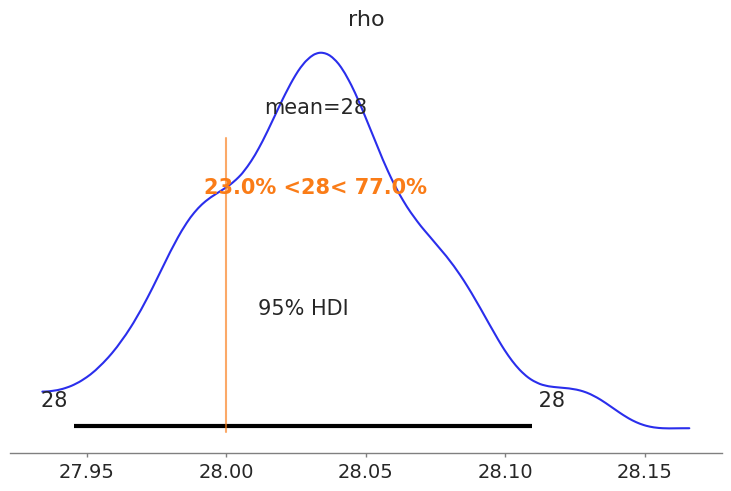

In [6]:
import arviz as az

az.style.use("arviz-white")

# For plotting reasons
parameter_posterior_samples = {"rho": posterior_samples["rho"]}

az.plot_posterior(
    parameter_posterior_samples, var_names=["rho"], hdi_prob=0.95, ref_val=28.0
)

plt.show()

As in the discrete-time inference tutorial, we also once again get smoothing estimates of the underlying states.

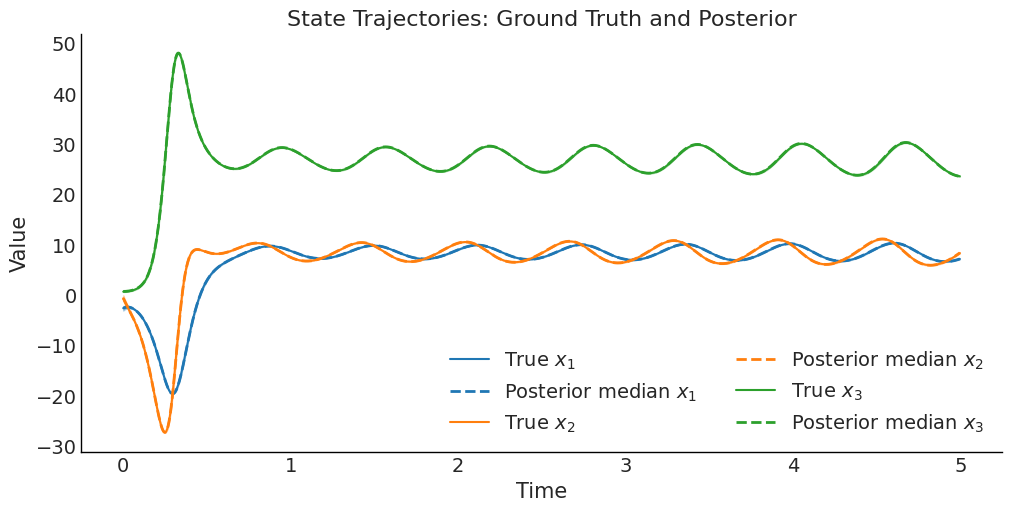

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

times = synthetic_samples["f_times"][0]
synthetic_states = synthetic_samples["f_states"][0]
states = posterior_samples["f_states"]

median = jnp.median(states, axis=0)  # (T, D)
p10 = jnp.percentile(states, 10, axis=0)  # (T, D)
p90 = jnp.percentile(states, 90, axis=0)  # (T, D)
state_colors = sns.color_palette("tab10", 3)

for d in range(3):
    plt.plot(
        times,
        synthetic_states[:, d],
        label=fr"True $x_{d + 1}$",
        color=state_colors[d],
    )
    plt.fill_between(times, p10[:, d], p90[:, d], alpha=0.3, color=state_colors[d])
    plt.plot(
        times,
        median[:, d],
        label=fr"Posterior median $x_{d + 1}$",
        lw=2,
        ls="--",
        color=state_colors[d],
    )

plt.title("State Trajectories: Ground Truth and Posterior")
plt.xlabel("Time")
plt.ylabel("Value")
sns.despine()
plt.legend(ncol=2)
plt.show()

We can also visualize the posterior distribtuion on initial conditions (i.e., $p(x_0 \,|\, y_{0:T})$) and compare it to the prior $p(x_0) \sim \mathcal{N}(0.0, 2.0^2 I)$.

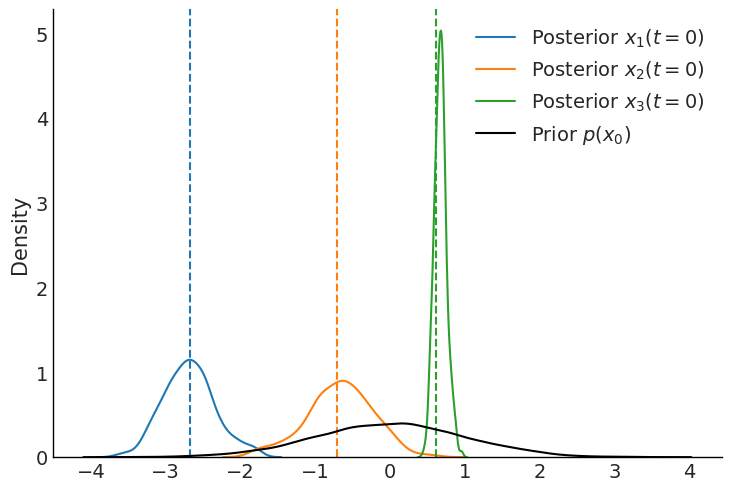

In [8]:
import numpy as np

state_colors = sns.color_palette("tab10", 3)

for d in range(3):
    sns.kdeplot(
        posterior_samples["x_0"][:, d],
        label=fr"Posterior $x_{d + 1}(t=0)$",
        color=state_colors[d],
    )
    plt.axvline(
        x=synthetic_samples["f_states"][0][0, d],
        linestyle="--",
        color=state_colors[d],
    )

sns.kdeplot(np.random.randn(10_000), label="Prior $p(x_0)$", color="black")
plt.legend(loc="upper right")
plt.show()

We can even look at joint posteriors $p(\rho, x_0 \,|\, y_{1:T})$. For example, let us look at $p(x_1(t=0))$ and $p(x_1(t=0), x_2(t=0))$:

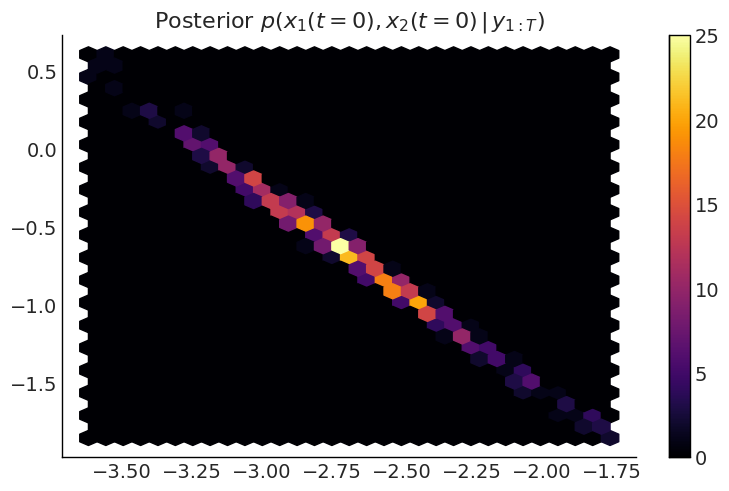

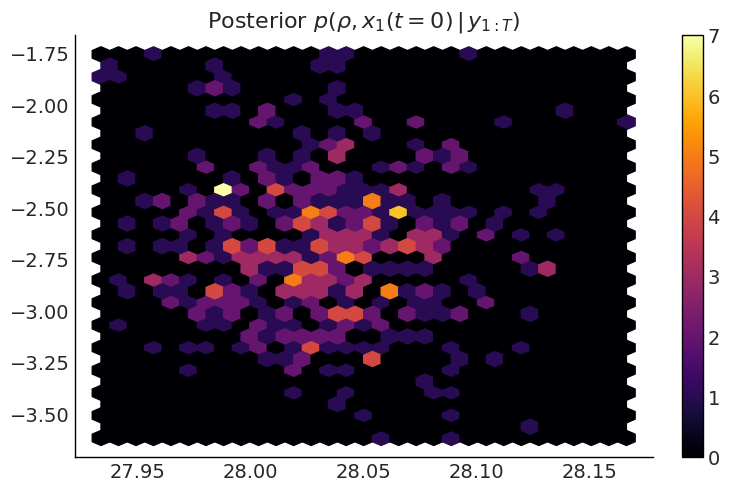

In [9]:
plt.title(r"Posterior $p(x_1(t=0), x_2(t=0) \,|\, y_{1:T})$")
plt.hexbin(
    posterior_samples["x_0"][:, 0],
    posterior_samples["x_0"][:, 1],
    cmap="inferno",
    gridsize=30,
)
plt.colorbar()
sns.despine()
plt.show()

plt.title(r"Posterior $p(\rho, x_1(t=0) \,|\, y_{1:T})$")
plt.hexbin(
    posterior_samples["rho"],
    posterior_samples["x_0"][:, 0],
    cmap="inferno",
    gridsize=30,
)
plt.colorbar()
plt.show()

We can see that the posterior of the initial conditions is tightly correlated, whilst the posterior of $\rho$ and $x_1(t=0)$ appears nearly independent.

### Rollout: Filter + Simulator with `predict_times`

To evaluate **rollout quality**—especially forecasts into the future—use **Filter + ODESimulator** with `predict_times`. Use a dense time grid from `obs_times[0]` to `obs_times[-1] + T` to show fitting between sparse data points and rollout past the final filtered time. The filter conditions on observations; the simulator rolls out trajectories at `predict_times`. ODEs are deterministic, so you get a single trajectory (no `n_simulations` band).

In [ ]:
from numpyro.handlers import seed, substitute, trace

from dynestyx import Filter
from dynestyx.inference.filter_configs import ContinuousTimeEKFConfig

# Sparse obs for rollout demo; predict_times dense from obs[0] to obs[-1]+T (between points + beyond)
obs_times_rollout = jnp.linspace(0.0, 5.0, 26)  # 26 sparse points
T_forecast = 2.0
predict_times = jnp.linspace(obs_times_rollout[0], obs_times_rollout[-1] + T_forecast, 141)

# Observations at sparse times (index into full trajectory)
idx = jnp.searchsorted(times, obs_times_rollout)
obs_values_rollout = observations[idx]
if obs_values_rollout.ndim == 1:
    obs_values_rollout = obs_values_rollout[:, None]

rho_post_mean = jnp.mean(posterior_samples["rho"])
substituted = substitute(continuous_time_deterministic_l63_model, data={"rho": rho_post_mean})

with ODESimulator():
    with Filter(filter_config=ContinuousTimeEKFConfig(record_filtered_states_mean=True)):
        with trace() as tr, seed(rng_seed=jr.PRNGKey(99)):
            substituted(
                obs_times=obs_times_rollout,
                obs_values=obs_values_rollout,
                predict_times=predict_times,
            )

pred_states = tr["f_predicted_states"]["value"]  # (T_pred, 3)
pred_times_arr = tr["f_predicted_times"]["value"]
if pred_times_arr.ndim > 1:
    pred_times_arr = pred_times_arr[0]
filtered_means = tr["f_filtered_states_mean"]["value"]

# Plot: true states, filtered means, observations, predicted trajectory
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
state_labels = [r"$x_1$", r"$x_2$", r"$x_3$"]
for i, ax in enumerate(axes):
    ax.plot(pred_times_arr, pred_states[:, i], "b-", label="Rollout", lw=1.5)
    ax.plot(times, states[:, i], "k--", label="True", lw=1)
    ax.plot(obs_times_rollout, filtered_means[:, i], "g.-", markersize=4, label="Filtered")
    if i == 0:
        ax.scatter(obs_times_rollout, obs_values_rollout[:, 0], color="C3", marker="x", s=30, label="Observed")
    ax.set_ylabel(state_labels[i])
    ax.legend(loc="upper right", fontsize=8)
    ax.axvline(obs_times_rollout[-1], color="gray", linestyle=":", alpha=0.7)
axes[0].set_title("Filter + ODESimulator: rollout with predict_times")
axes[-1].set_xlabel("time")
plt.tight_layout()
plt.show()

### Simulator alone with `predict_times`

You can also use **ODESimulator alone** (no Filter) for forward simulation at `predict_times`. Pass `obs_times=None`, `obs_values=None`, and `predict_times` to generate a trajectory. ODEs are deterministic, so you get a single trajectory.

In [ ]:
# Simulator alone: forward simulation at predict_times (no observations)
predict_times_sim = jnp.linspace(0.0, 6.0, 121)
substituted_sim = substitute(continuous_time_deterministic_l63_model, data={"rho": rho_post_mean})

with ODESimulator():
    with trace() as tr_sim, seed(rng_seed=jr.PRNGKey(88)):
        substituted_sim(
            obs_times=None,
            obs_values=None,
            predict_times=predict_times_sim,
        )

sim_states = tr_sim["f_states"]["value"]  # (T, 3)
sim_times = tr_sim["f_times"]["value"]
if sim_times.ndim > 1:
    sim_times = sim_times[0]

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
state_labels = [r"$x_1$", r"$x_2$", r"$x_3$"]
for i, ax in enumerate(axes):
    ax.plot(sim_times, sim_states[:, i], "b-", label="Simulator alone", lw=1.5)
    ax.plot(times, states[:, i], "k--", label="True (from earlier)", lw=1)
    ax.set_ylabel(state_labels[i])
    ax.legend(loc="upper right", fontsize=8)
axes[0].set_title("ODESimulator alone: forward simulation with predict_times")
axes[-1].set_xlabel("time")
plt.tight_layout()
plt.show()

**Next:** [Part 7 — HMMs and multiple trajectories](../07_hmm/)